# Neural Network Regression — Building Energy Efficiency

In this exercise you will build regression models using TensorFlow/Keras to predict the **energy load** of buildings.

### The Dataset
The [UCI Energy Efficiency dataset](https://archive.ics.uci.edu/ml/datasets/Energy+efficiency) contains simulated data for 768 buildings. Each building is described by 8 architectural features, and the goal is to predict how much energy is needed to heat or cool it.

| Feature | Description |
|---|---|
| Relative Compactness | How compact the building shape is (higher = more compact) |
| Surface Area | Total surface area (m²) |
| Wall Area | Total wall area (m²) |
| Roof Area | Roof area (m²) |
| Overall Height | Building height (m) |
| Orientation | 2=North, 3=East, 4=South, 5=West |
| Glazing Area | Proportion of floor area that is glazed (windows) |
| Glazing Area Distribution | Where glazing is distributed: 0=uniform, 1–5=varied |

**Target variables:**
- `Heating_Load` — energy needed for heating (kWh/m²)
- `Cooling_Load` — energy needed for cooling (kWh/m²)

You will predict **Heating Load** throughout this exercise. The bonus section asks you to switch to Cooling Load.

---
> Beat a simple linear regression baseline using a neural network.

## Step 1: Imports

Run this cell — no changes needed.

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.layers import Normalization

print('TensorFlow version:', tf.__version__)

I0000 00:00:1773230125.086708   93847 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773230125.087607   93847 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773230125.169733   93847 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773230130.981416   93847 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773230130.985054   93847 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


## Step 2: Load the Data

The dataset is provided as a CSV file alongside this notebook.

**Task:** Load `ENB2012_data.csv` (on Moodle) into a DataFrame called `df`.

Then call `df.head()` and `df.shape` to get a feel for it.

In [2]:
# Load the dataset
df = pd.read_csv('ENB2012_data.csv')

# Shape
print('Dataset shape:', df.shape)

# Display the first few rows of the dataset
df.head()

Dataset shape: (1296, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


## Step 3: Rename Columns and Inspect

The default column names aren't very readable. Run the rename cell, then answer the questions.

**Questions:**
- How many buildings are in the dataset? **There are 1296 buildings in the dataset when using df.shape[0].**
- Are there any missing values? (use `.isna().sum()`)
- What is the range of Heating Load values? (use `.describe()`)

In [3]:
df.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution',
    'Heating_Load', 'Cooling_Load'
]
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [4]:
# Check for missing values and explore the data
print('Missing values:')
print(df.isnull().sum())

# Stats
print('\nDataset description:')
print(df.describe())

# How many buildings
print('\nNumber of buildings:', df.shape[0])

df = df.dropna()

print('\nMissing values after dropping nulls:')
print(df.isnull().sum())

Missing values:
Relative_Compactness    528
Surface_Area            528
Wall_Area               528
Roof_Area               528
Overall_Height          528
Orientation             528
Glazing_Area            528
Glazing_Distribution    528
Heating_Load            528
Cooling_Load            528
dtype: int64

Dataset description:
       Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.375000  294.000000  140.875000   
50%                0.750000    673.750000  318.500000  183.750000   
75%                0.830000    741.125000  343.000000  220.500000   
max                0.980000    808.500000  416.500000  220.500000   

       Overall_Height  Orientation  Glazing_Are

## Step 4: Explore the Data

Before modelling, it's always worth looking at what we're trying to predict.

**Task:** Plot a histogram of `Heating_Load`. Does it look normally distributed? Are there obvious clusters?

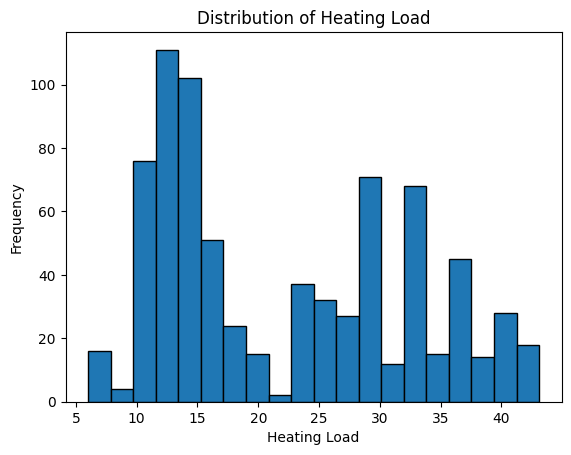

In [5]:
# Plot a histogram of Heating_Load
plt.hist(df['Heating_Load'], bins=20, edgecolor='k')
plt.title('Distribution of Heating Load')
plt.xlabel('Heating Load')
plt.ylabel('Frequency')
plt.show()

**Task:** Plot a scatter matrix to explore which features seem most correlated with `Heating_Load`.

Hint: `pd.plotting.scatter_matrix(df, figsize=(12, 10), alpha=0.3)` gives a quick overview.

Which features look most useful to you?

array([[<Axes: xlabel='Relative_Compactness', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Surface_Area', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Wall_Area', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Roof_Area', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Overall_Height', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Orientation', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Glazing_Area', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Glazing_Distribution', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Heating_Load', ylabel='Relative_Compactness'>,
        <Axes: xlabel='Cooling_Load', ylabel='Relative_Compactness'>],
       [<Axes: xlabel='Relative_Compactness', ylabel='Surface_Area'>,
        <Axes: xlabel='Surface_Area', ylabel='Surface_Area'>,
        <Axes: xlabel='Wall_Area', ylabel='Surface_Area'>,
        <Axes: xlabel='Roof_Area', ylabel='Surface_Area'>,
        <Axes: xlabel='Overall_Height'

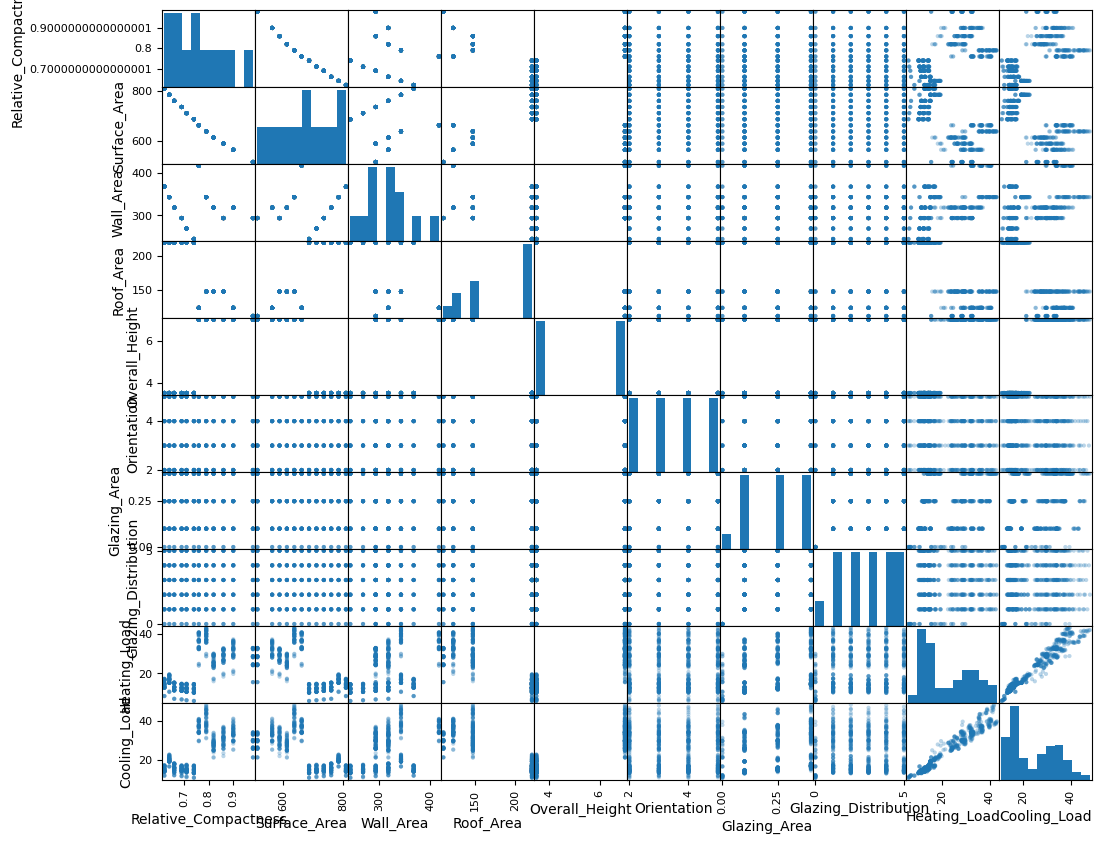

In [6]:
pd.plotting.scatter_matrix(df, figsize=(12, 10), alpha=0.3)

## Step 5: Set Up Features and Target

**Task:** Define your feature matrix `X` and target vector `y`.

- `X` should contain all 8 input features (everything except `Heating_Load` and `Cooling_Load`)
- `y` should be `Heating_Load`

Then do a train/test split — 80% train, 20% test, `random_state=42`.

In [7]:
feature_cols = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution']

X = df[feature_cols]
y = df['Heating_Load']

# Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 6: Baseline — sklearn Linear Regression

Before building a neural network, establish a baseline with a simple model. If your NN can't beat this, something has gone wrong.

**Task:**
1. Fit a `LinearRegression` model on the training data
2. Predict on the test set
3. Print the **Mean Absolute Error (MAE)** on the test set

Note this number — you'll be comparing against it throughout the exercise.

In [8]:
# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

print(f'Linear Regression Test MAE: {mean_absolute_error(y_test, y_pred)}')

Linear Regression Test MAE: 2.18204702212792


## Step 7: Normalise the Input Features

The 8 features have very different scales (e.g. Surface Area is in the hundreds, Glazing Area is 0–1). Neural networks are sensitive to this.

**Task:**
1. Create a `Normalization()` layer called `normalizer`
2. Call `.adapt()` on `X_train.values`

> Always adapt on **training data only** — including test data leaks information about the test set into your model.

In [9]:
# Create a normalization layer
normalizer = Normalization()
normalizer.adapt(X_train.values)

E0000 00:00:1773230137.768122   93847 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Step 8: Build a Neural Network

**Task:** Build a `Sequential` model called `model` with this architecture:

| Layer | Type | Units | Activation |
|---|---|---|---|
| 1 | Normalization | — | — |
| 2 | Dense | 64 | relu |
| 3 | Dense | 64 | relu |
| 4 | Dense | 1 | none (linear output) |

Compile with `Adam(learning_rate=0.001)` and loss `mean_absolute_error`.

Call `model.summary()` — how many trainable parameters does it have?

In [10]:
# Build a simple neural network model
modelNN = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

modelNN.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001), loss='mae')
modelNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (614, 8)               │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17 (72.00 B)

## Step 9: Train the Neural Network

**Task:** Train your model for **100 epochs** with `validation_split=0.2`. Store the result in `history`.

In [11]:
# Train on 100 epochs
historyNN = modelNN.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 21.8112 - val_loss: 20.0545
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.5238 - val_loss: 18.4933
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.6080 - val_loss: 15.9935
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.5638 - val_loss: 12.1759
Epoch 5/100


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.0948 - val_loss: 7.3408
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.0964 - val_loss: 5.4530
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1017 - val_loss: 4.8212
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.4185 - val_loss: 4.2765
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8910 - val_loss: 3.8185
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5680 - val_loss: 3.6011
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.3282 - val_loss: 3.4563
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1675 - val_loss: 3.3142
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.0601 - val_loss: 3.2395
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.9634 - val_loss: 3.1357
Epoch 15/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8848 - val_loss: 3.1123
Epoch 16/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7952 - 

## Step 10: Plot Training and Validation Loss

**Task:** Plot the loss curves using the helper function below.

- Is the model still improving at epoch 100, or has it levelled off?
- Is there a gap between training and validation loss? What does that suggest?

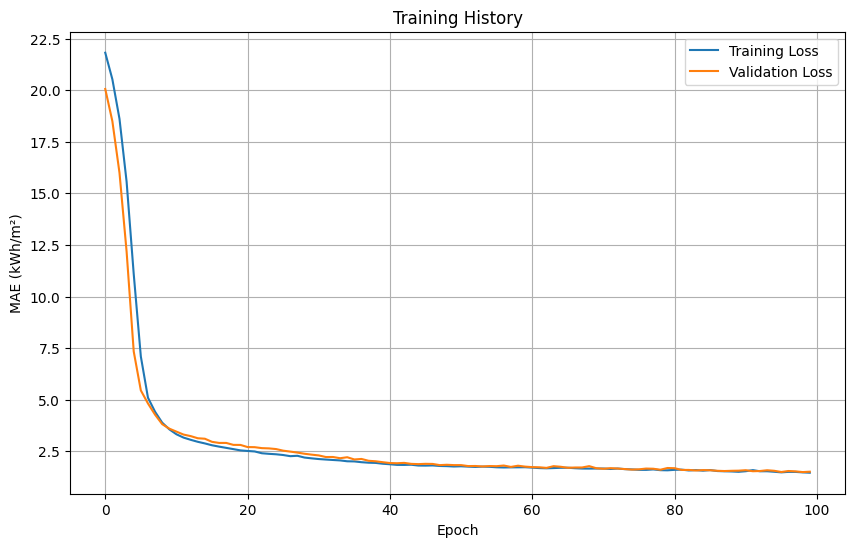

In [12]:
def plot_loss(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MAE (kWh/m²)')
    plt.legend()
    plt.grid(True)
    plt.title('Training History')
    plt.show()

# call plot_loss here
plot_loss(historyNN)

## Step 11: Evaluate on the Test Set

**Task:** Use `model.evaluate(X_test.values, y_test)` to get the final test MAE.

Fill in the table:

| Model | Test MAE |
|---|---|
| Linear Regression (sklearn) | 2.182 |
| Neural Network (TensorFlow) | 0.576 |

Did the NN beat the baseline? By how much?

In [13]:
modelNN.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6191 


1.619092583656311

## Step 12: Visualise Predictions vs Actual

A scatter plot of predicted vs actual is a great way to see how well a regression model is doing. A perfect model would be a straight diagonal line.

**Task:**
1. Generate predictions: `y_pred = model.predict(X_test.values)`
2. Scatter plot `y_test` (x-axis) vs `y_pred` (y-axis)
3. Add a diagonal reference line with `plt.plot([min, max], [min, max])`

Where does your model struggle most?

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


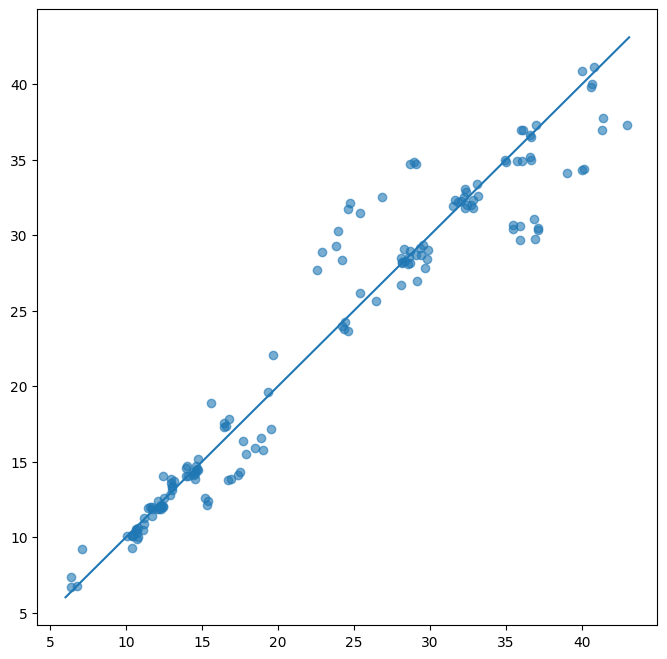

In [14]:
y_pred = modelNN.predict(X_test.values)

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()])

## Step 13: Experiment — Change the Architecture

Try at least **one** of the following and record the effect on test MAE:

- Add a third hidden layer
- Change the number of units (try 32 or 128)
- Change the learning rate (try 0.01 or 0.0001)
- Train for more epochs (e.g. 200)

What made the biggest difference?

In [15]:
# Architecture tried:
# Result:

# Build a simple neural network model
modelNN_2 = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

modelNN_2.compile(optimizer=tf.optimizers.Adam(learning_rate=0.01), loss='mae')
modelNN_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17 (72.00 B)

In [16]:
# Train on 100 epochs
historyNN_2 = modelNN_2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
)

Epoch 1/200


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 14.5236 - val_loss: 8.1309
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4114 - val_loss: 4.6496
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6698 - val_loss: 3.5781
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9969 - val_loss: 2.8396
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6177 - val_loss: 2.5059
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3413 - val_loss: 2.3028
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3751 - val_loss: 2.3012
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1327 - val_loss: 2.0659
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0823 - val_loss: 1.9991
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0258 - val_loss: 1.8989
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9982 - val_loss: 1.9442
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.9148 - val

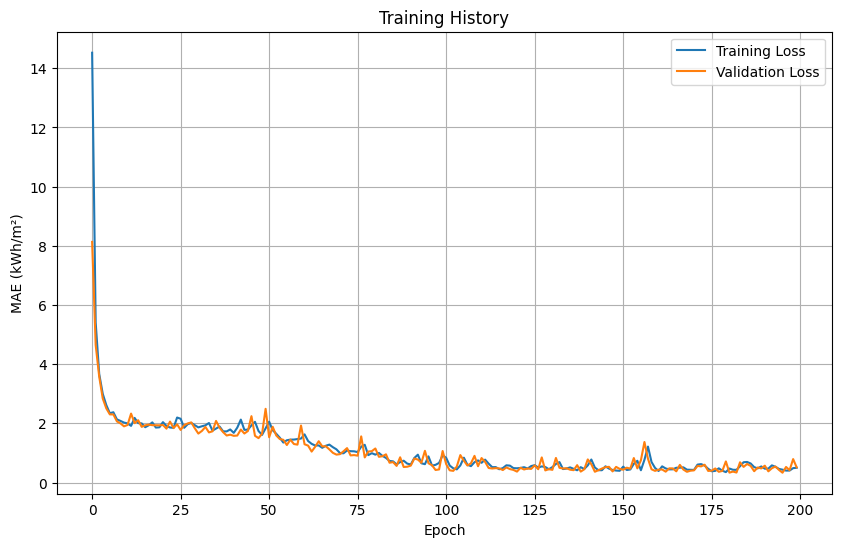

In [17]:
plot_loss(historyNN_2)

## Step 14: Reflection Questions

Answer the following:

1. Why do we normalise inputs for a neural network, but sklearn's `LinearRegression` doesn't need it?
2. What does validation loss tell you that training loss alone cannot?
3. Looking at your predictions vs actual scatter plot — are there buildings the model consistently gets wrong? Why might that be?
4. If a student said *"I'll just use 10 hidden layers with 1000 units each"* — what would you tell them?

1: NNs are very sensitive to different numeric values, whereas LR models are not as they "calculate the relationship between input variables (features) and the target variable independently".

2:

---
## Bonus A: Early Stopping

Rather than guessing the right number of epochs, use Early Stopping to let Keras decide.

**Task:** Re-train your best model with:
```python
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
```
Set `epochs=1000`. How many epochs did it actually run? Is the result better?

In [18]:
# your code here


## Bonus B: Predict Cooling Load Instead

The dataset has a second target: `Cooling_Load`.

**Task:** Repeat the full exercise predicting `Cooling_Load` instead.

- Is the task easier or harder? (compare MAEs)
- Do the same features seem important?
- Does the same architecture work as well?

In [19]:
# your code here
